In [1]:
!nvidia-smi

Wed Nov 19 13:55:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             27W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import libraries

In [2]:
!git clone https://github.com/VuTrinhNguyenHoang/eX-LAViTs.git

Cloning into 'eX-LAViTs'...
remote: Enumerating objects: 432, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 432 (delta 47), reused 53 (delta 24), pack-reused 351 (from 1)
Receiving objects: 100% (432/432), 171.19 KiB | 8.15 MiB/s, done.
Resolving deltas: 100% (275/275), done.


In [3]:
%cd eX-LAViTs
!ls -l

/kaggle/working/eX-LAViTs
total 28
drwxr-xr-x 2 root root 4096 Nov 19 13:55 configs
drwxr-xr-x 2 root root 4096 Nov 19 13:55 datasets
drwxr-xr-x 2 root root 4096 Nov 19 13:55 notebooks
-rw-r--r-- 1 root root  315 Nov 19 13:55 README.md
-rw-r--r-- 1 root root   93 Nov 19 13:55 requirements.txt
drwxr-xr-x 4 root root 4096 Nov 19 13:55 src
drwxr-xr-x 2 root root 4096 Nov 19 13:55 tests


In [4]:
# Repository
from src.models.linear_vit import create_linear_attention_vit
from src.models.explainability import ViTGradCAM, IntegratedGradient, Rollout, LAGRA
from src.utils.training import (
    create_run_directory, setup_logging, get_optimizer, get_scheduler,
    train_model, count_parameters, load_checkpoint
)
from src.pretrained import freeze_all_except_last_k_blocks, unfreeze_all
from src.utils.metrics import compute_loss_and_accuracy, compute_classification_metrics, evaluate_xai_method_dataset, evaluate_class_specificity_cosine
from src.utils.visualization import save_all_plots, create_training_summary_plot
from src.explain import visualize_methods

# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.transforms.autoaugment import AutoAugment, AutoAugmentPolicy
import timm
from sklearn.model_selection import train_test_split

from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import math
from tqdm.auto import tqdm
import os

## Config

In [5]:
run_name = "run001"

LR = 2e-4
WD = 1e-4

EPOCHS = 100
warmup_epochs = 10
remaining_epochs = EPOCHS - warmup_epochs

PATIENCE = 5

BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
print(NUM_WORKERS, DEVICE)

4 cuda


## Datasets

In [6]:
# Load data
data_dir = Path("/kaggle/input/animals10")
data_img = data_dir / "raw-img"

translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

def build_df():
    rows = []

    for cls_name in os.listdir(data_img):
        cls_dir = os.path.join(data_img, cls_name)
        if not os.path.isdir(cls_dir):
            continue

        # nhãn sau khi mapping (ví dụ: "cane" -> "dog")
        label = translate.get(cls_name, cls_name)

        for fname in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, fname)
            rows.append({"image": img_path, "labels": label})

    df = pd.DataFrame(rows, columns=["image", "labels"])
    return df

df = build_df()

labels = sorted(df["labels"].unique())
labels2id = {lbl: idx for idx, lbl in enumerate(labels)}

df["labels"] = df["labels"].map(labels2id)

print(labels2id)
df.head()

{'butterfly': 0, 'cat': 1, 'chicken': 2, 'cow': 3, 'dog': 4, 'elephant': 5, 'horse': 6, 'sheep': 7, 'spider': 8, 'squirrel': 9}


,image,labels
0,/kaggle/input/animals10/raw-img/cavallo/OIP-md...,6
1,/kaggle/input/animals10/raw-img/cavallo/OIP-TP...,6
2,/kaggle/input/animals10/raw-img/cavallo/OIP-jl...,6
3,/kaggle/input/animals10/raw-img/cavallo/OIP-F4...,6
4,/kaggle/input/animals10/raw-img/cavallo/OIP-UF...,6


In [7]:
df["labels"].value_counts(True)

labels
4    0.185760
8    0.184155
2    0.118339
6    0.100195
0    0.080675
3    0.071279
9    0.071126
7    0.069521
1    0.063715
5    0.055235
Name: proportion, dtype: float64

In [8]:
# Split train/valid/test
train_df, tmp_df = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["labels"])
valid_df, test_df = train_test_split(tmp_df, test_size=0.5, random_state=SEED, stratify=tmp_df["labels"])

train_df.shape, valid_df.shape, test_df.shape

((18325, 2), (3927, 2), (3927, 2))

### Create Dataset

In [9]:
class DS(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rows = self.df.iloc[idx]
        path, y = rows["image"], rows["labels"]
        img = Image.open(path).convert("RGB")

        return self.transform(img), y

In [10]:
# Transform
train_transform = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

test_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [11]:
n_classes = len(df["labels"].unique())

train_dataset = DS(train_df, train_transform)
valid_dataset = DS(valid_df, test_transform)
test_dataset = DS(test_df, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

len(train_loader), len(valid_loader), len(test_loader)

(287, 62, 62)

In [12]:
batch_test = next(iter(train_loader))
batch_test[0].shape, batch_test[1].shape

(torch.Size([64, 3, 224, 224]), torch.Size([64]))

## Explain

In [19]:
model_name = "vit_tiny_patch16_224"
checkpoint_path = "/kaggle/input/ex-lavit/pytorch/default/3/linear_vit_tiny_animal.pth"

model = create_linear_attention_vit(
    model_name,
    pretrained=False,
    num_classes=n_classes
)

load_checkpoint(
    checkpoint_path,
    model,
    device=DEVICE
)

model.to(DEVICE).eval()

Creating Linear Attention ViT: vit_tiny_patch16_224
    Pretrained: False
    Classes: 10
    Image size: 224
    Original parameters: 5,526,346
Replacing attention layers with LinearMultiheadAttention...
    Kernel: elu
    Epsilon: 1e-06
   Block 0: dim=192, heads=3, mlp_ratio=4.0
   Block 1: dim=192, heads=3, mlp_ratio=4.0
   Block 2: dim=192, heads=3, mlp_ratio=4.0
   Block 3: dim=192, heads=3, mlp_ratio=4.0
   Block 4: dim=192, heads=3, mlp_ratio=4.0
   Block 5: dim=192, heads=3, mlp_ratio=4.0
   Block 6: dim=192, heads=3, mlp_ratio=4.0
   Block 7: dim=192, heads=3, mlp_ratio=4.0
   Block 8: dim=192, heads=3, mlp_ratio=4.0
   Block 9: dim=192, heads=3, mlp_ratio=4.0
   Block 10: dim=192, heads=3, mlp_ratio=4.0
   Block 11: dim=192, heads=3, mlp_ratio=4.0
Successfully replaced 12 attention blocks
    Total parameters: 5,526,346
    Trainable parameters: 5,526,346


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): LinearAttentionBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): LinearMultiheadAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (out_proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (fc2): Linear(in_features=768, out_features=192, bias=True)
       

In [20]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

### LAGRA

In [21]:
idx = np.random.randint(len(test_dataset))

x, y_true = test_dataset[idx] # test sample
xb = x.unsqueeze(0).to(DEVICE)

In [22]:
proposal_model = LAGRA(model, has_cls=True, blocks_attr="blocks")

out = proposal_model.attribute(xb, use_logits=True)

In [23]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.1086, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.0987, device='cuda:0', grad_fn=<MeanBackward0>))

### GradCAM

In [24]:
gradcam_model = ViTGradCAM(model, has_cls=True)

out = gradcam_model.attribute(xb)

In [25]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.7014, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.6303, device='cuda:0', grad_fn=<MeanBackward0>))

### Integrated Gradients

In [26]:
ig_model = IntegratedGradient(model, m_steps=32)

out = ig_model.attribute(xb)

In [27]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.2219, device='cuda:0'),
 tensor(0.0560, device='cuda:0'))

### Rollout

In [28]:
rollout_model = Rollout(model, has_cls=True)

out = rollout_model.attribute(xb)

In [29]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.1424, device='cuda:0'),
 tensor(0.1381, device='cuda:0'))

## Visualization

3507


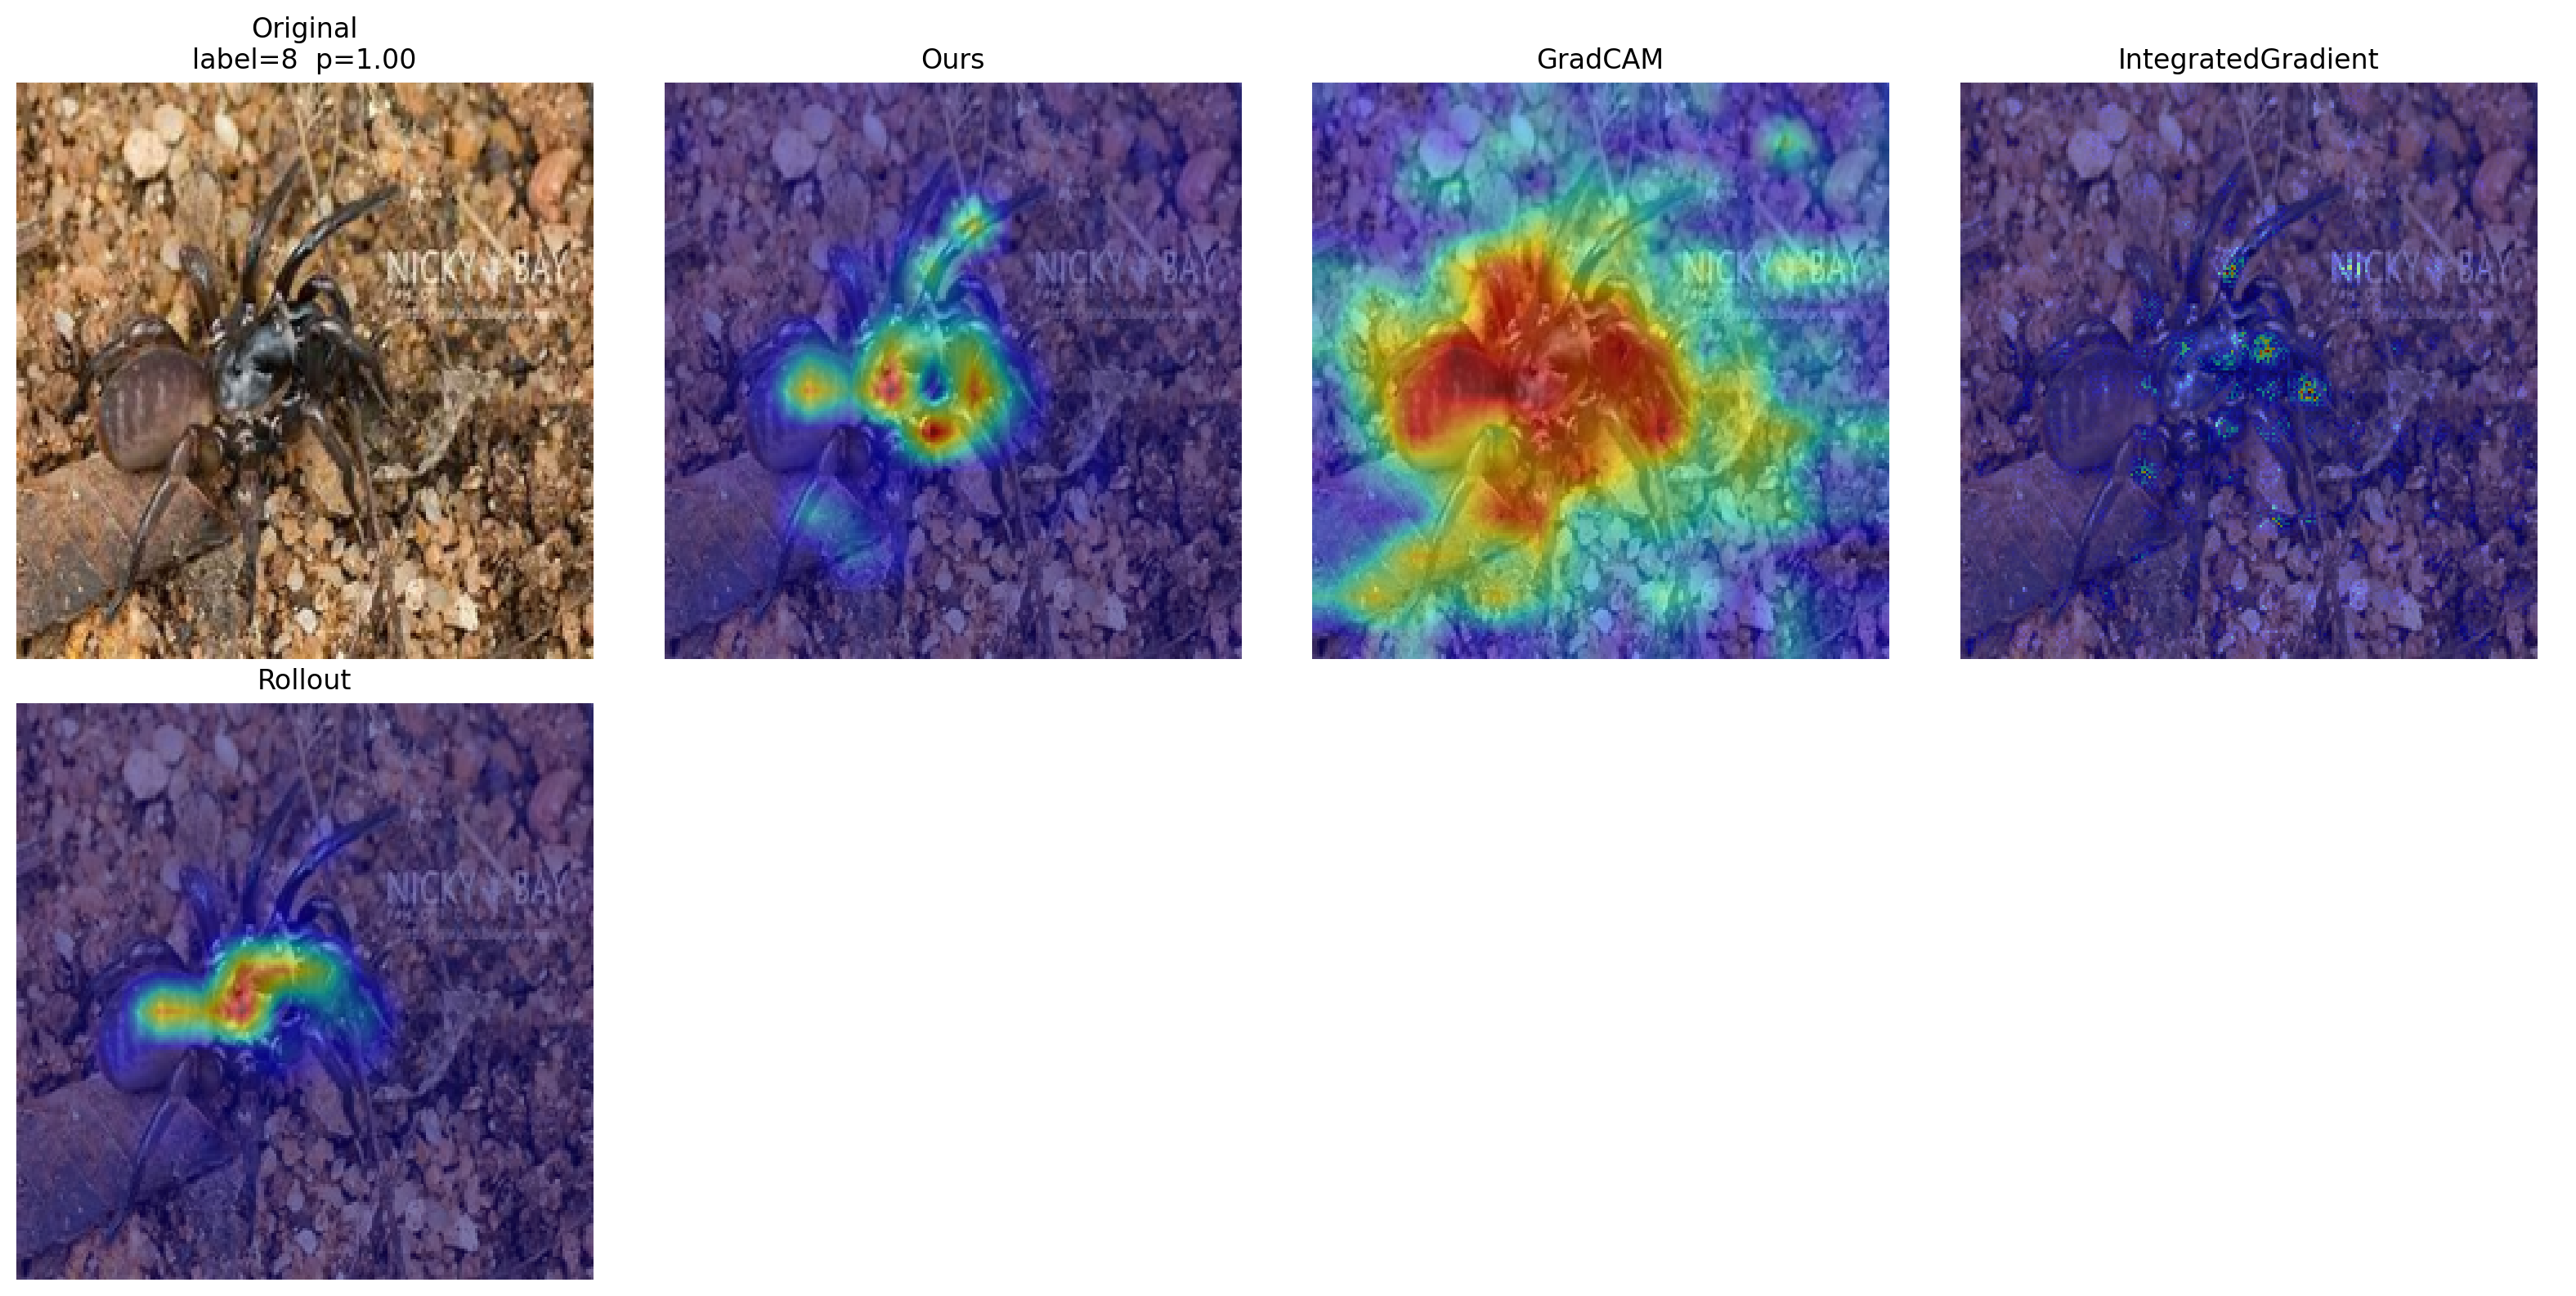

In [30]:
idx = np.random.randint(len(test_dataset))
print(idx)

_ = visualize_methods(
    test_dataset, idx,
    {
        "Ours": proposal_model,
        "GradCAM": gradcam_model,
        "IntegratedGradient": ig_model,
        "Rollout": rollout_model
    },
    use_pred=True,
    device=DEVICE,
)

## Evaluate Explain methods

In [31]:
methods = {
    "Ours": proposal_model,
    "GradCAM": gradcam_model,
    "IG": ig_model,
    "Rollout": rollout_model
}

results = {}
for name, attr in methods.items():
    print(f"Evaluating {name}...")
    stats_faith = evaluate_xai_method_dataset(
        attributor=attr,
        dataset=test_dataset,
        device=DEVICE,
        use_pred=True,
        max_samples=640,
        steps=20,
        baseline=None,
        use_logits=True,
        verbose_every=50,
    )

    stats_cs = evaluate_class_specificity_cosine(
        attributor=attr,
        dataset=test_dataset,
        device=DEVICE,
        max_samples=640,
        use_logits=True,
        use_pred=True,
        verbose_every=50,
    )

    metrics = {
        **stats_faith,
        "cosine_cs_mean": stats_cs["cosine_cs_mean"],
        "cosine_cs_std": stats_cs["cosine_cs_std"],
    }
    results[name] = metrics
    print(f"Results for {name}: {metrics}")
    print("-" * 50)

Evaluating Ours...
[50/640] AUC_del_mean=0.2981, AUC_ins_mean=0.7907, entropy_mean=0.8432
[100/640] AUC_del_mean=0.3326, AUC_ins_mean=0.8056, entropy_mean=0.8510
[150/640] AUC_del_mean=0.3499, AUC_ins_mean=0.7959, entropy_mean=0.8498
[200/640] AUC_del_mean=0.3473, AUC_ins_mean=0.7909, entropy_mean=0.8499
[250/640] AUC_del_mean=0.3570, AUC_ins_mean=0.7983, entropy_mean=0.8499
[300/640] AUC_del_mean=0.3626, AUC_ins_mean=0.7952, entropy_mean=0.8505
[350/640] AUC_del_mean=0.3657, AUC_ins_mean=0.7943, entropy_mean=0.8494
[400/640] AUC_del_mean=0.3653, AUC_ins_mean=0.7984, entropy_mean=0.8487
[450/640] AUC_del_mean=0.3583, AUC_ins_mean=0.7968, entropy_mean=0.8479
[500/640] AUC_del_mean=0.3593, AUC_ins_mean=0.7960, entropy_mean=0.8471
[550/640] AUC_del_mean=0.3617, AUC_ins_mean=0.7998, entropy_mean=0.8471
[600/640] AUC_del_mean=0.3632, AUC_ins_mean=0.8007, entropy_mean=0.8471
[50/640] cosine_cs_mean=0.5997
[100/640] cosine_cs_mean=0.6073
[150/640] cosine_cs_mean=0.6108
[200/640] cosine_cs_mea

In [32]:
results

{'Ours': {'auc_del_mean': 0.3645040523268976,
  'auc_ins_mean': 0.802412665766329,
  'entropy_mean': 0.8466980232270916,
  'gini_mean': 0.976331252368982,
  'n_samples': 640,
  'cosine_cs_mean': 0.6202776702353731,
  'cosine_cs_std': 0.20038552718005195},
 'GradCAM': {'auc_del_mean': 0.6698492740880273,
  'auc_ins_mean': 0.6231558752826521,
  'entropy_mean': 0.9965796149218795,
  'gini_mean': 0.9947193794811028,
  'n_samples': 640,
  'cosine_cs_mean': 0.40975219410024694,
  'cosine_cs_std': 0.3522663841055117},
 'IG': {'auc_del_mean': 0.48997579103624195,
  'auc_ins_mean': 0.7529690986604199,
  'entropy_mean': 0.9481081189320989,
  'gini_mean': 0.9908547911465575,
  'n_samples': 640,
  'cosine_cs_mean': 0.6953069861978293,
  'cosine_cs_std': 0.08792069071237024},
 'Rollout': {'auc_del_mean': 0.423739278105686,
  'auc_ins_mean': 0.7408368150088709,
  'entropy_mean': 0.8253520549443104,
  'gini_mean': 0.9790825177842635,
  'n_samples': 640,
  'cosine_cs_mean': 1.000000008009374,
  'cosin